## Task 1: Understand the Business Problem
1. What is the business about?

   PayFlow Business Solutions is a B2B financial operations company that helps small and medium-sized businesses manage invoicing, payment collection, and accounts receivable. The company provides invoice tracking, payment reminders, online payment portals, and financial reporting dashboards.

2. What problem is the business trying to solve?

   The business is trying to reduce the problem of late invoice payments. Late payments can create cash-flow problems, increase administrative work, and make it harder for businesses to plan operations.

3. What decision can machine learning help the business make?

   Machine learning can help PayFlow predict whether an invoice is likely to be paid late before the due date passes. This can help the business decide which invoices need early reminders, extra follow up, or account manager support.

4. What is the target variable in the dataset?

   The target variable is **Late_Payment**.  
   A value of **Yes** means the invoice was paid late.  
   A value of **No** means the invoice was paid on time.

5. What are the input features?

   The input features include customer information, invoice information, payment history, and service interaction variables:

   - Customer_Segment
   - Industry
   - Region
   - Invoice_Month
   - Invoice_Amount
   - Payment_Terms_Days
   - Customer_Tenure_Months
   - Prior_Late_Payments
   - Avg_Days_To_Pay
   - Days_Since_Last_Order
   - Dispute_Flag
   - Reminder_Count
   - Online_Portal_Use
   - Early_Payment_Discount_Offered
   - Credit_Score_Band


6. Why is this prediction useful for the business?

   This prediction is useful because it allows PayFlow to act before invoices become overdue. The company can then send reminders, provide account manager support, resolve disputes earlier, and improve cash-flow planning.

   

## Task 2: Prepare the Data

In [1]:
import pandas as pd
import numpy as np

from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report

In [2]:
file_path = "payflow_invoice_late_payment_dataset.xlsx"

df = pd.read_excel(file_path)

print("Dataset loaded successfully!")

print("Dataset shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Dataset shape: (360, 17)


,Invoice_ID,Customer_Segment,Industry,Region,Invoice_Month,Invoice_Amount,Payment_Terms_Days,Customer_Tenure_Months,Prior_Late_Payments,Avg_Days_To_Pay,Days_Since_Last_Order,Dispute_Flag,Reminder_Count,Online_Portal_Use,Early_Payment_Discount_Offered,Credit_Score_Band,Late_Payment
0,INV-20260001,Small Business,Construction,Prairies,Aug,5851.94,30,28,1,42,156,No,3,Yes,No,Medium,Yes
1,INV-20260002,Small Business,Healthcare Services,British Columbia,Aug,3224.65,30,34,2,47,153,Yes,2,Yes,No,High,No
2,INV-20260003,Mid-Market,Retail,Prairies,Dec,17946.67,30,12,2,38,19,No,2,No,No,High,Yes
3,INV-20260004,Small Business,Retail,British Columbia,Sep,5131.03,15,25,5,49,107,No,4,Yes,No,Low,Yes
4,INV-20260005,Mid-Market,Technology,Alberta,Aug,17553.63,60,14,0,61,46,No,2,Yes,No,Medium,Yes


In [3]:
print("Dataset Shape")

print(df.shape)

Dataset Shape
(360, 17)


In [4]:
print("First Five Rows of the Dataset")

display(df.head())

First Five Rows of the Dataset


,Invoice_ID,Customer_Segment,Industry,Region,Invoice_Month,Invoice_Amount,Payment_Terms_Days,Customer_Tenure_Months,Prior_Late_Payments,Avg_Days_To_Pay,Days_Since_Last_Order,Dispute_Flag,Reminder_Count,Online_Portal_Use,Early_Payment_Discount_Offered,Credit_Score_Band,Late_Payment
0,INV-20260001,Small Business,Construction,Prairies,Aug,5851.94,30,28,1,42,156,No,3,Yes,No,Medium,Yes
1,INV-20260002,Small Business,Healthcare Services,British Columbia,Aug,3224.65,30,34,2,47,153,Yes,2,Yes,No,High,No
2,INV-20260003,Mid-Market,Retail,Prairies,Dec,17946.67,30,12,2,38,19,No,2,No,No,High,Yes
3,INV-20260004,Small Business,Retail,British Columbia,Sep,5131.03,15,25,5,49,107,No,4,Yes,No,Low,Yes
4,INV-20260005,Mid-Market,Technology,Alberta,Aug,17553.63,60,14,0,61,46,No,2,Yes,No,Medium,Yes


In [5]:
print("Last Five Rows of the Dataset")

display(df.tail())

Last Five Rows of the Dataset


,Invoice_ID,Customer_Segment,Industry,Region,Invoice_Month,Invoice_Amount,Payment_Terms_Days,Customer_Tenure_Months,Prior_Late_Payments,Avg_Days_To_Pay,Days_Since_Last_Order,Dispute_Flag,Reminder_Count,Online_Portal_Use,Early_Payment_Discount_Offered,Credit_Score_Band,Late_Payment
355,INV-20260356,Small Business,Manufacturing,British Columbia,Apr,6359.48,15,8,1,26,9,No,0,Yes,No,Medium,No
356,INV-20260357,Mid-Market,Retail,Quebec,Oct,15507.29,30,12,0,24,9,No,1,No,No,Medium,No
357,INV-20260358,Mid-Market,Manufacturing,Alberta,Feb,26096.82,30,7,0,22,57,Yes,2,Yes,No,Medium,No
358,INV-20260359,Mid-Market,Professional Services,British Columbia,Jan,8104.53,30,55,3,32,152,No,4,Yes,No,High,Yes
359,INV-20260360,Small Business,Professional Services,Atlantic Canada,Dec,4340.22,45,2,2,54,14,No,0,No,No,Low,Yes


In [6]:
print("Column Names")

print(df.columns.tolist())

Column Names
['Invoice_ID', 'Customer_Segment', 'Industry', 'Region', 'Invoice_Month', 'Invoice_Amount', 'Payment_Terms_Days', 'Customer_Tenure_Months', 'Prior_Late_Payments', 'Avg_Days_To_Pay', 'Days_Since_Last_Order', 'Dispute_Flag', 'Reminder_Count', 'Online_Portal_Use', 'Early_Payment_Discount_Offered', 'Credit_Score_Band', 'Late_Payment']


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 360 entries, 0 to 359
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Invoice_ID                      360 non-null    object 
 1   Customer_Segment                360 non-null    object 
 2   Industry                        360 non-null    object 
 3   Region                          360 non-null    object 
 4   Invoice_Month                   360 non-null    object 
 5   Invoice_Amount                  360 non-null    float64
 6   Payment_Terms_Days              360 non-null    int64  
 7   Customer_Tenure_Months          360 non-null    int64  
 8   Prior_Late_Payments             360 non-null    int64  
 9   Avg_Days_To_Pay                 360 non-null    int64  
 10  Days_Since_Last_Order           360 non-null    int64  
 11  Dispute_Flag                    360 non-null    object 
 12  Reminder_Count                  360 

In [8]:
print("Missing Values in Each Column")

missing_values = df.isnull().sum()

display(missing_values)

Missing Values in Each Column


Invoice_ID                        0
Customer_Segment                  0
Industry                          0
Region                            0
Invoice_Month                     0
Invoice_Amount                    0
Payment_Terms_Days                0
Customer_Tenure_Months            0
Prior_Late_Payments               0
Avg_Days_To_Pay                   0
Days_Since_Last_Order             0
Dispute_Flag                      0
Reminder_Count                    0
Online_Portal_Use                 0
Early_Payment_Discount_Offered    0
Credit_Score_Band                 0
Late_Payment                      0
dtype: int64

In [9]:
print("Number of Duplicate Rows")

duplicate_rows = df.duplicated().sum()

print(duplicate_rows)

Number of Duplicate Rows
0


In [10]:
display(df.describe())

,Invoice_Amount,Payment_Terms_Days,Customer_Tenure_Months,Prior_Late_Payments,Avg_Days_To_Pay,Days_Since_Last_Order,Reminder_Count
count,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000
mean,20228.199528,35.041667,41.808333,0.975000,43.000000,93.933333,1.358333
std,22699.497765,13.016421,26.617992,1.274099,15.516008,52.201143,1.276284
min,678.530000,15.000000,2.000000,0.000000,8.000000,3.000000,0.000000
25%,4888.875000,30.000000,21.000000,0.000000,31.750000,49.750000,0.000000
50%,10224.800000,30.000000,38.000000,1.000000,41.000000,96.000000,1.000000
75%,26169.710000,45.000000,55.000000,1.000000,54.000000,137.000000,2.000000
max,94400.730000,60.000000,120.000000,8.000000,97.000000,180.000000,6.000000


In [11]:
target_column = "Late_Payment"

print("Target variable:")

print(target_column)

Target variable:
Late_Payment


In [12]:
print("Target variable values:")

print(df[target_column].unique())

Target variable values:
['Yes' 'No']


In [13]:
print("Target class distribution:")

target_counts = df[target_column].value_counts()

display(target_counts)

Target class distribution:


Late_Payment
No     201
Yes    159
Name: count, dtype: int64

In [14]:
df_clean = df.drop_duplicates()

df_clean = df_clean.drop(columns=["Invoice_ID"])

df_clean.head()

,Customer_Segment,Industry,Region,Invoice_Month,Invoice_Amount,Payment_Terms_Days,Customer_Tenure_Months,Prior_Late_Payments,Avg_Days_To_Pay,Days_Since_Last_Order,Dispute_Flag,Reminder_Count,Online_Portal_Use,Early_Payment_Discount_Offered,Credit_Score_Band,Late_Payment
0,Small Business,Construction,Prairies,Aug,5851.94,30,28,1,42,156,No,3,Yes,No,Medium,Yes
1,Small Business,Healthcare Services,British Columbia,Aug,3224.65,30,34,2,47,153,Yes,2,Yes,No,High,No
2,Mid-Market,Retail,Prairies,Dec,17946.67,30,12,2,38,19,No,2,No,No,High,Yes
3,Small Business,Retail,British Columbia,Sep,5131.03,15,25,5,49,107,No,4,Yes,No,Low,Yes
4,Mid-Market,Technology,Alberta,Aug,17553.63,60,14,0,61,46,No,2,Yes,No,Medium,Yes


In [15]:
X = df_clean.drop(columns=[target_column])

y = df_clean[target_column]

print("X and y have been defined successfully.")

X and y have been defined successfully.


In [16]:
feature_columns = df_clean.drop(columns=[target_column]).columns.tolist()

print("Feature columns used for prediction:")
print(feature_columns)

Feature columns used for prediction:
['Customer_Segment', 'Industry', 'Region', 'Invoice_Month', 'Invoice_Amount', 'Payment_Terms_Days', 'Customer_Tenure_Months', 'Prior_Late_Payments', 'Avg_Days_To_Pay', 'Days_Since_Last_Order', 'Dispute_Flag', 'Reminder_Count', 'Online_Portal_Use', 'Early_Payment_Discount_Offered', 'Credit_Score_Band']


In [17]:
categorical_features = X.select_dtypes(include=["object"]).columns
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
Index(['Customer_Segment', 'Industry', 'Region', 'Invoice_Month',
       'Dispute_Flag', 'Online_Portal_Use', 'Early_Payment_Discount_Offered',
       'Credit_Score_Band'],
      dtype='object')

Numerical features:
Index(['Invoice_Amount', 'Payment_Terms_Days', 'Customer_Tenure_Months',
       'Prior_Late_Payments', 'Avg_Days_To_Pay', 'Days_Since_Last_Order',
       'Reminder_Count'],
      dtype='object')


In [18]:
print("Shape of X:")

print(X.shape)

print("Shape of y:")

print(y.shape)

Shape of X:
(360, 15)
Shape of y:
(360,)


In [19]:
print("First five rows of X:")

display(X.head())

First five rows of X:


,Customer_Segment,Industry,Region,Invoice_Month,Invoice_Amount,Payment_Terms_Days,Customer_Tenure_Months,Prior_Late_Payments,Avg_Days_To_Pay,Days_Since_Last_Order,Dispute_Flag,Reminder_Count,Online_Portal_Use,Early_Payment_Discount_Offered,Credit_Score_Band
0,Small Business,Construction,Prairies,Aug,5851.94,30,28,1,42,156,No,3,Yes,No,Medium
1,Small Business,Healthcare Services,British Columbia,Aug,3224.65,30,34,2,47,153,Yes,2,Yes,No,High
2,Mid-Market,Retail,Prairies,Dec,17946.67,30,12,2,38,19,No,2,No,No,High
3,Small Business,Retail,British Columbia,Sep,5131.03,15,25,5,49,107,No,4,Yes,No,Low
4,Mid-Market,Technology,Alberta,Aug,17553.63,60,14,0,61,46,No,2,Yes,No,Medium


In [20]:
print("First five values of y:")

display(y.head())

First five values of y:


0    Yes
1     No
2    Yes
3    Yes
4    Yes
Name: Late_Payment, dtype: object

In [21]:
target_distribution = y.value_counts()

print("Target class distribution:")

display(target_distribution)

Target class distribution:


Late_Payment
No     201
Yes    159
Name: count, dtype: int64

In [22]:
preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("numerical", "passthrough", numerical_features)
    ]
)

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (288, 15)
X_test shape: (72, 15)
y_train shape: (288,)
y_test shape: (72,)


## Task 3: Train a Decision Tree Classification Model

In [24]:
dt_model = Pipeline(
    steps=[ ("preprocessor", preprocessor), ("classifier", DecisionTreeClassifier(random_state=42))
    ]
)

In [25]:
dt_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Customer_Segment', 'Industry', 'Region', 'Invoice_Month',
       'Dispute_Flag', 'Online_Portal_Use', 'Early_Payment_Discount_Offered',
       'Credit_Score_Band'],
      dtype='object')),
                                                 ('numerical', 'passthrough',
                                                  Index(['Invoice_Amount', 'Payment_Terms_Days', 'Customer_Tenure_Months',
       'Prior_Late_Payments', 'Avg_Days_To_Pay', 'Days_Since_Last_Order',
       'Reminder_Count'],
      dtype='object'))])),
                ('classifier', DecisionTreeClassifier(random_state=42))])

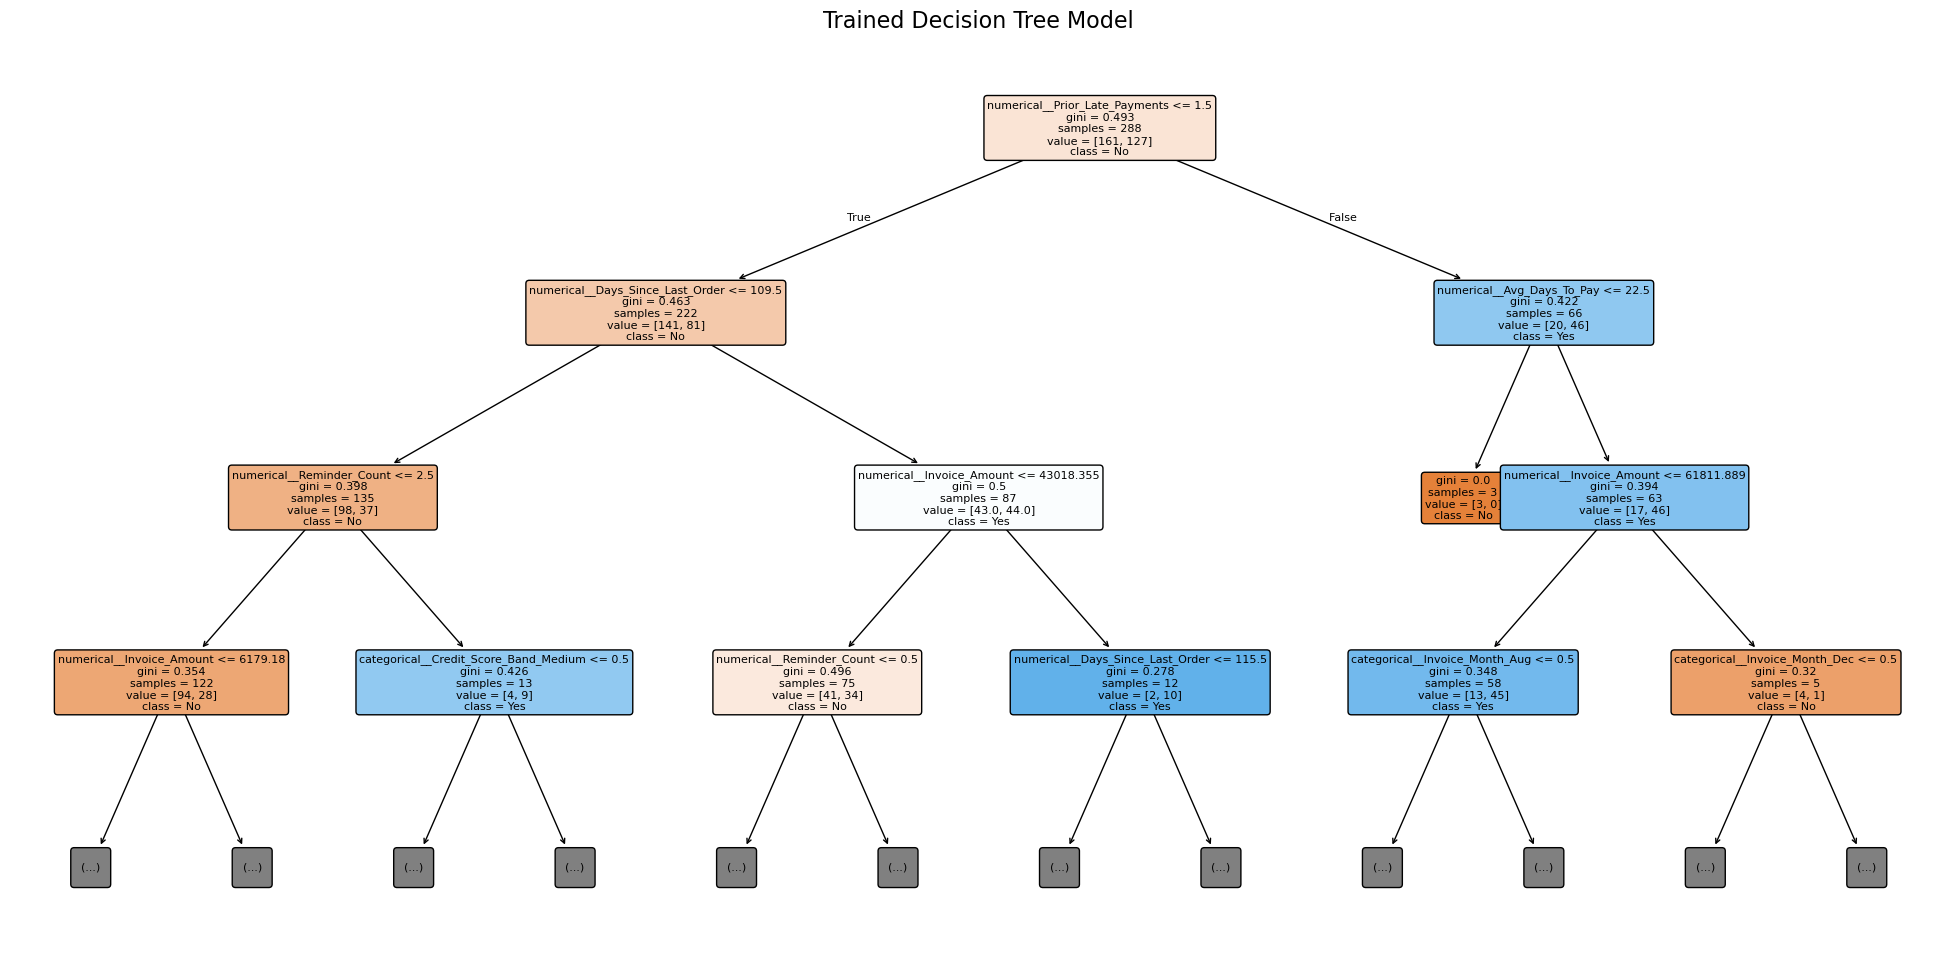

In [26]:
feature_names = dt_model.named_steps["preprocessor"].get_feature_names_out()

class_names = dt_model.named_steps["classifier"].classes_

plt.figure(figsize=(25, 12))

plot_tree(
    dt_model.named_steps["classifier"],
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=3
)

plt.title("Trained Decision Tree Model", fontsize=16)
plt.show()

The chart above shows the trained Decision Tree model. Each box represents a decision rule used by the model to classify invoices as likely late or likely on time. Only the first few levels of the tree are shown because the full tree may be too large and difficult to read. This visualization helps explain how the model makes predictions, but the model results should still be evaluated using testing accuracy, confusion matrix, precision, recall, and F1-score.

In [27]:
tree_depth = dt_model.named_steps["classifier"].get_depth()
tree_leaves = dt_model.named_steps["classifier"].get_n_leaves()

tree_complexity = pd.DataFrame({
    "Model": ["Decision Tree"],
    "Tree Depth": [tree_depth],
    "Number of Leaves": [tree_leaves]
})

tree_complexity

,Model,Tree Depth,Number of Leaves
0,Decision Tree,11,71


The tree depth and number of leaves help show how complex the Decision Tree is. A very deep tree with many leaves may memorize the training data, which can lead to overfitting.

In [28]:
y_train_pred = dt_model.predict(X_train)
y_test_pred = dt_model.predict(X_test)

In [29]:
dt_train_accuracy = accuracy_score(y_train, y_train_pred)
dt_test_accuracy = accuracy_score(y_test, y_test_pred)

print("Decision Tree Training Accuracy:", dt_train_accuracy)
print("Decision Tree Testing Accuracy:", dt_test_accuracy)

Decision Tree Training Accuracy: 1.0
Decision Tree Testing Accuracy: 0.5694444444444444


In [30]:
dt_cm = confusion_matrix(y_test, y_test_pred, labels=["No", "Yes"])

print("Decision Tree Confusion Matrix:")
print(dt_cm)

Decision Tree Confusion Matrix:
[[24 16]
 [15 17]]


In [31]:
dt_cm_table = pd.DataFrame(
    dt_cm,
    index=["Actual No", "Actual Yes"],
    columns=["Predicted No", "Predicted Yes"]
)

dt_cm_table

,Predicted No,Predicted Yes
Actual No,24,16
Actual Yes,15,17


In [32]:
tn = dt_cm[0, 0]
fp = dt_cm[0, 1]
fn = dt_cm[1, 0]
tp = dt_cm[1, 1]

confusion_explanation = pd.DataFrame({
    "Result Type": ["True Negative", "False Positive", "False Negative", "True Positive"],
    "Business Meaning": [
        "Invoice was paid on time, and the model predicted on time",
        "Invoice was paid on time, but the model predicted late",
        "Invoice was paid late, but the model predicted on time",
        "Invoice was paid late, and the model predicted late"
    ],
    "Count": [tn, fp, fn, tp]
})

confusion_explanation

,Result Type,Business Meaning,Count
0,True Negative,"Invoice was paid on time, and the model predic...",24
1,False Positive,"Invoice was paid on time, but the model predic...",16
2,False Negative,"Invoice was paid late, but the model predicted...",15
3,True Positive,"Invoice was paid late, and the model predicted...",17


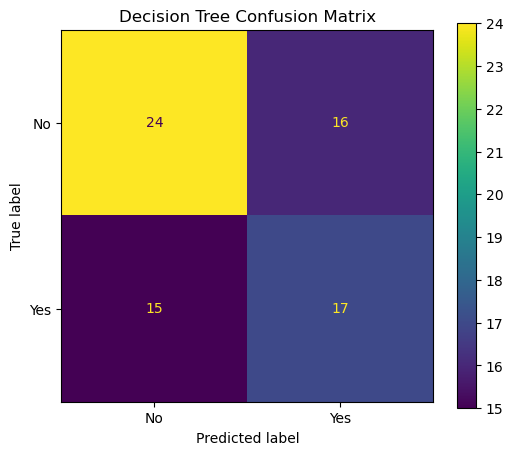

In [33]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=dt_cm,
    display_labels=["No", "Yes"]
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax)
plt.title("Decision Tree Confusion Matrix")
plt.show()

In [34]:
dt_accuracy = accuracy_score(y_test, y_test_pred)
dt_precision = precision_score(y_test, y_test_pred, pos_label="Yes")
dt_recall = recall_score(y_test, y_test_pred, pos_label="Yes")
dt_f1 = f1_score(y_test, y_test_pred, pos_label="Yes")

print("Decision Tree Accuracy:", dt_accuracy)
print("Decision Tree Precision:", dt_precision)
print("Decision Tree Recall:", dt_recall)
print("Decision Tree F1-score:", dt_f1)

Decision Tree Accuracy: 0.5694444444444444
Decision Tree Precision: 0.5151515151515151
Decision Tree Recall: 0.53125
Decision Tree F1-score: 0.5230769230769231


In [35]:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

          No       0.62      0.60      0.61        40
         Yes       0.52      0.53      0.52        32

    accuracy                           0.57        72
   macro avg       0.57      0.57      0.57        72
weighted avg       0.57      0.57      0.57        72



In [36]:
accuracy_difference = dt_train_accuracy - dt_test_accuracy

print("Training Accuracy:", dt_train_accuracy)
print("Testing Accuracy:", dt_test_accuracy)
print("Difference:", accuracy_difference)

if accuracy_difference > 0.10:
    print("The Decision Tree model may be overfitting because the training accuracy is much higher than the testing accuracy.")
else:
    print("The Decision Tree model does not show strong signs of overfitting because the training and testing accuracy are close.")

Training Accuracy: 1.0
Testing Accuracy: 0.5694444444444444
Difference: 0.4305555555555556
The Decision Tree model may be overfitting because the training accuracy is much higher than the testing accuracy.


In [37]:
feature_names = dt_model.named_steps["preprocessor"].get_feature_names_out()

importance_values = dt_model.named_steps["classifier"].feature_importances_

dt_feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_values
})

dt_feature_importance = dt_feature_importance.sort_values(
    by="Importance",
    ascending=False
)

dt_feature_importance.head(10)

,Feature,Importance
41,numerical__Days_Since_Last_Order,0.202993
36,numerical__Invoice_Amount,0.124146
39,numerical__Prior_Late_Payments,0.098765
40,numerical__Avg_Days_To_Pay,0.095374
42,numerical__Reminder_Count,0.062015
38,numerical__Customer_Tenure_Months,0.056140
7,categorical__Industry_Retail,0.042683
31,categorical__Early_Payment_Discount_Offered_No,0.033335
12,categorical__Region_Ontario,0.024994
15,categorical__Invoice_Month_Apr,0.021278


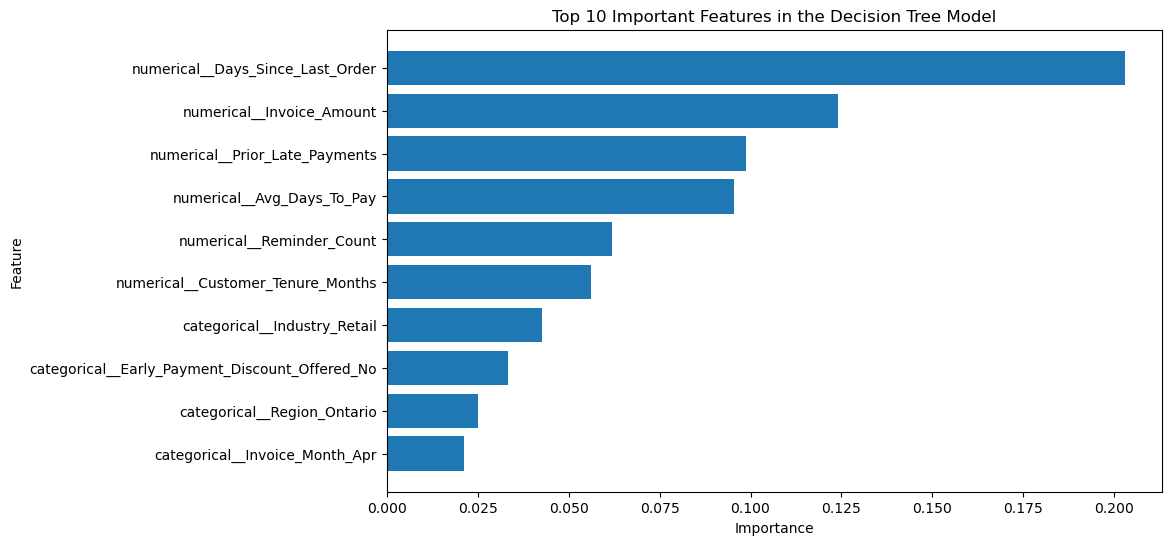

In [38]:
top_10_features = dt_feature_importance.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_10_features["Feature"], top_10_features["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Important Features in the Decision Tree Model")
plt.gca().invert_yaxis()
plt.show()

In [39]:
most_important_feature = dt_feature_importance.iloc[0]["Feature"]
most_important_value = dt_feature_importance.iloc[0]["Importance"]

print("Most Important Feature:", most_important_feature)
print("Importance Value:", most_important_value)

Most Important Feature: numerical__Days_Since_Last_Order
Importance Value: 0.2029933108039866


## Task 4: Business Interpretation of Model Results

In [40]:
model_summary = pd.DataFrame({
    "Metric": [
        "Training Accuracy",
        "Testing Accuracy",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],
    "Decision Tree Result": [
        dt_train_accuracy,
        dt_test_accuracy,
        dt_accuracy,
        dt_precision,
        dt_recall,
        dt_f1
    ]
})

model_summary

,Metric,Decision Tree Result
0,Training Accuracy,1.000000
1,Testing Accuracy,0.569444
2,Accuracy,0.569444
3,Precision,0.515152
4,Recall,0.531250
5,F1-score,0.523077


In [41]:
dt_feature_importance.head(5)

,Feature,Importance
41,numerical__Days_Since_Last_Order,0.202993
36,numerical__Invoice_Amount,0.124146
39,numerical__Prior_Late_Payments,0.098765
40,numerical__Avg_Days_To_Pay,0.095374
42,numerical__Reminder_Count,0.062015


**Write a short interpretation based on your model results and the business plan.**


**How well did the Decision Tree model perform?**  
The Decision Tree model had a moderate to weak testing performance. The testing accuracy was 0.5694, meaning the model correctly predicted about 56.94% of the invoices in the testing data. The precision for Late_Payment = Yes was 0.5152, meaning that about 51.52% of the invoices predicted as late were actually late. The recall was 0.5313, meaning the model correctly identified about 53.13% of the invoices that were truly paid late. The F1-score was 0.5231, which shows a balance between precision and recall. Overall, the model gives PayFlow a basic starting point, but the performance is not strong enough to fully rely on without human review.

**Is there a large difference between training accuracy and testing accuracy?**  
Yes. The training accuracy was 1.0000, while the testing accuracy was 0.5694. This is a large difference of about 0.4306, or 43.06 percentage points.

**Does the model show signs of overfitting? Why or why not?**  
Yes. The model shows signs of overfitting because it performed perfectly on the training data with 100.00% training accuracy, but it performed much worse on the testing data with only 56.94% testing accuracy. This suggests that the Decision Tree may have learned the training data too closely instead of learning general patterns that work well on new invoices.

**Which evaluation metric is most important for this business problem?**  
Recall for Late_Payment = Yes is especially important because PayFlow wants to identify as many truly risky invoices as possible before they become overdue. In this model, the recall was 0.5313, meaning the model only caught about 53.13% of the truly late invoices. This should be improved because missing late invoices can create cash-flow problems. However, precision should also be monitored because the precision was 0.5152, meaning some customers predicted as late would actually pay on time.

**What do false positives mean in this business context?**  
A false positive means the model predicted that an invoice would be paid late, but the invoice was actually paid on time. In this model, there were 16 false positives. This means PayFlow may spend extra staff time sending reminders or following up with customers who did not actually need extra attention. This could increase workload and may annoy reliable customers.

**What do false negatives mean in this business context?**  
A false negative means the model predicted that an invoice would be paid on time, but the invoice was actually paid late. In this model, there were 15 false negatives. This is more serious because PayFlow misses the chance to follow up early. False negatives can lead to cash-flow problems, delayed collection action, and higher collection effort later.

**Which features were most important in the Decision Tree model?**  
The most important features were shown in the feature importance table above. The top features included Days_Since_Last_Order, Invoice_Amount, Prior_Late_Payments, Avg_Days_To_Pay, and Reminder_Count. These were the variables the Decision Tree used most strongly when making predictions.

**How can these important features help the business make better decisions?**  
These important features can help PayFlow understand which customer and invoice factors are most connected to late payment risk. For example, if a customer has more prior late payments or a higher average number of days to pay, PayFlow may send earlier reminders or assign account manager support. If the invoice amount is large, PayFlow may monitor it more closely because a late payment could have a bigger impact on cash flow. If reminder count is high, it may show payment friction and the customer may need additional follow-up or support.

**What is one possible limitation or bias in the model or dataset?**  
One limitation is that the dataset is simplified and may not include all real-world factors that affect payment behavior. Real payment behavior may depend on customer financial stress, contract terms, approval workflows, seasonal business cycles, economic conditions, or the relationship between the customer and account manager. Because of this, the model may not capture every reason why an invoice is paid late.

**Why should human judgment still be used when making business decisions based on model results?**  
Human judgment should still be used because the model should support business decisions, not replace people. The testing accuracy was only 56.94%, and the model made both false positive and false negative errors. Staff should review high-risk predictions before taking action, especially for large invoices, important customers, or disputed invoices. This helps PayFlow avoid unfair treatment and protect customer relationships.

In [42]:
print("Final Conclusion")

print("This notebook showed how a Decision Tree model can be used for invoice late payment prediction.")

print("The model used in this assignment is: Decision Tree")

print("From a business perspective, this model can help PayFlow identify invoices that may be at risk of late payment.")

print("However, The model should be used as a decision-support tool and should not replace human judgment.")

Final Conclusion
This notebook showed how a Decision Tree model can be used for invoice late payment prediction.
The model used in this assignment is: Decision Tree
From a business perspective, this model can help PayFlow identify invoices that may be at risk of late payment.
However, The model should be used as a decision-support tool and should not replace human judgment.


In [43]:
import os

output_folder = "outputs"

os.makedirs(output_folder, exist_ok=True)

print("Output folder is ready:", output_folder)

Output folder is ready: outputs


In [44]:
df_clean.to_csv("outputs/cleaned_payflow_invoice_late_payment.csv", index=False)

print("Cleaned dataset has been saved successfully.")

Cleaned dataset has been saved successfully.


In [45]:
model_summary.to_csv("outputs/final_model_summary.csv", index=False)

print("Final model summary has been saved successfully.")

Final model summary has been saved successfully.


In [46]:
dt_feature_importance.to_csv("outputs/decision_tree_feature_importance.csv", index=False)

print("Feature importance results have been saved successfully.")

Feature importance results have been saved successfully.


In [47]:
project_summary = f"""
Decision Tree Classification Project: PayFlow Invoice Late Payment Prediction

Business Problem:
Predict whether an invoice will be paid late based on customer information, invoice details, payment behavior, and account-related features.

Model Used:
Decision Tree Classification Model

Evaluation Metrics:
Accuracy, Precision, Recall, F1-Score, Confusion Matrix, Training Accuracy, and Testing Accuracy

Main Results:
Training Accuracy: {dt_train_accuracy:.4f}
Testing Accuracy: {dt_test_accuracy:.4f}
Accuracy: {dt_accuracy:.4f}
Precision: {dt_precision:.4f}
Recall: {dt_recall:.4f}
F1-Score: {dt_f1:.4f}

Main Business Value:
The model can help PayFlow identify invoices that may be at risk of late payment. This can support early reminders, account manager support, dispute resolution, and cash-flow planning.

Limitation:
The model showed signs of overfitting because training accuracy was much higher than testing accuracy. The dataset is also simplified and may not include all real-world payment factors.

Responsible AI Reminder:
The model should support human decision-making and should not replace staff review.
"""

with open("outputs/project_summary.txt", "w") as file:

    file.write(project_summary)

print("Project summary file has been saved successfully.")

Project summary file has been saved successfully.


In [48]:
github_checklist = pd.DataFrame({

    "Submission Item": [
        "Completed Jupyter Notebook",
        "Dataset file, if allowed",
        "Cleaned dataset output",
        "Model summary output",
        "Feature importance output",
        "Decision Tree visualization",
        "README file",
        "Business interpretation",
        "All notebook cells run without errors",
        "GitHub repository link submitted on Canvas"
    ],

    "Status": [
        "Required",
        "Required if allowed",
        "Recommended",
        "Recommended",
        "Recommended",
        "Recommended",
        "Required",
        "Required",
        "Required",
        "Required"
    ]
})

display(github_checklist)

,Submission Item,Status
0,Completed Jupyter Notebook,Required
1,"Dataset file, if allowed",Required if allowed
2,Cleaned dataset output,Recommended
3,Model summary output,Recommended
4,Feature importance output,Recommended
5,Decision Tree visualization,Recommended
6,README file,Required
7,Business interpretation,Required
8,All notebook cells run without errors,Required
9,GitHub repository link submitted on Canvas,Required


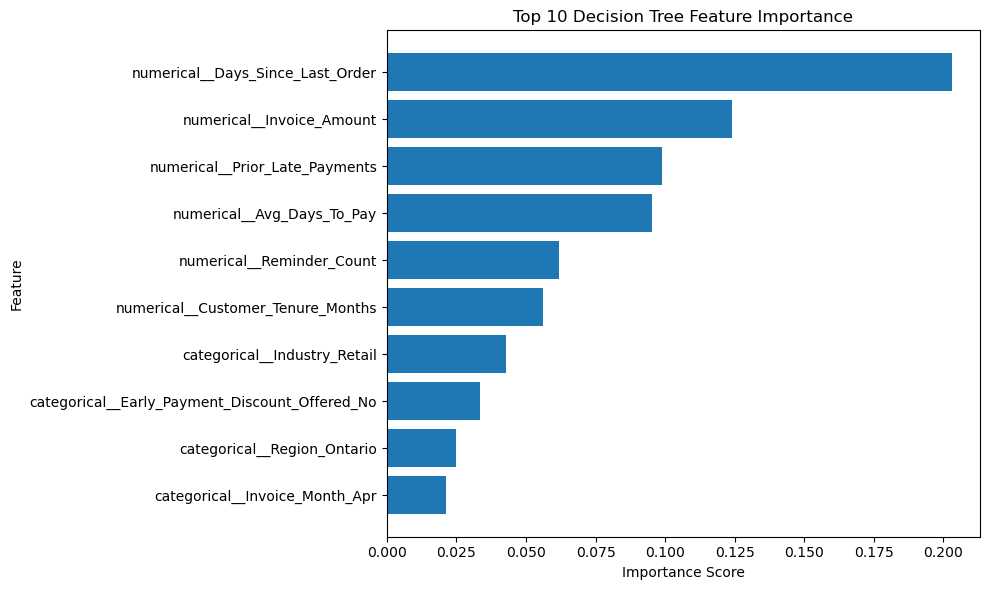

Chart saved as: outputs/top_decision_tree_features.png


In [49]:
import matplotlib.pyplot as plt

os.makedirs("outputs", exist_ok=True)

github_top_features = dt_feature_importance.head(10)

github_top_features_plot = github_top_features.sort_values(by="Importance", ascending=True)

plt.figure(figsize=(10, 6))

plt.barh(
    github_top_features_plot["Feature"],
    github_top_features_plot["Importance"]
)

plt.title("Top 10 Decision Tree Feature Importance")

plt.xlabel("Importance Score")

plt.ylabel("Feature")

plt.tight_layout()

plt.savefig("outputs/top_decision_tree_features.png", dpi=300, bbox_inches="tight")

plt.show()

print("Chart saved as: outputs/top_decision_tree_features.png")

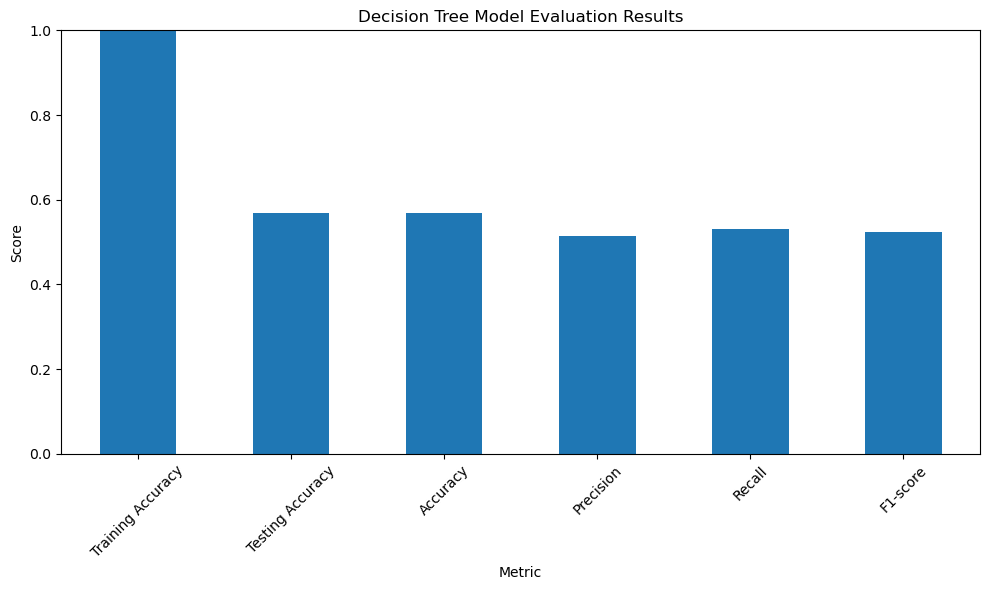

Chart saved as: outputs/decision_tree_model_results.png


In [50]:
github_model_summary = model_summary.set_index("Metric")

plt.figure(figsize=(10, 6))

github_model_summary["Decision Tree Result"].plot(kind="bar")

plt.title("Decision Tree Model Evaluation Results")

plt.ylabel("Score")

plt.ylim(0, 1)

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("outputs/decision_tree_model_results.png", dpi=300, bbox_inches="tight")

plt.show()

print("Chart saved as: outputs/decision_tree_model_results.png")